<a href="https://colab.research.google.com/github/dbright123/Dbot-Advance/blob/main/lstm_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import MetaTrader5 as mt5
import numpy as np
import pandas as pd





In [17]:
print("MetaTrader5 package author: ",mt5.__author__)
print("MetaTrader5 package version: ",mt5.__version__)

trade_active = mt5.initialize("C:\\Program Files\\MetaTrader 5\\terminal64.exe")

print(trade_active)

if not trade_active:
    print('Initialization failed, check internet connection. You must have Meta Trader 5 installed.')
    mt5.shutdown()

else:
    print(mt5.account_info()._asdict())
    print("\n")
    print(mt5.terminal_info()._asdict())
    print("\n")
    print(mt5.symbols_total())
    

MetaTrader5 package author:  MetaQuotes Ltd.
MetaTrader5 package version:  5.0.5200
True
{'login': 32122224, 'trade_mode': 0, 'leverage': 1000, 'limit_orders': 50, 'margin_so_mode': 0, 'trade_allowed': True, 'trade_expert': True, 'margin_mode': 2, 'currency_digits': 2, 'fifo_close': False, 'balance': 10000.0, 'credit': 0.0, 'profit': 0.0, 'equity': 10000.0, 'margin': 7.95, 'margin_free': 9992.05, 'margin_level': 125786.16352201256, 'margin_so_call': 100.0, 'margin_so_so': 50.0, 'margin_initial': 0.0, 'margin_maintenance': 0.0, 'assets': 0.0, 'liabilities': 0.0, 'commission_blocked': 0.0, 'name': 'Micheal Bright Omage', 'server': 'Deriv-Demo', 'currency': 'USD', 'company': 'Deriv.com Limited'}


{'community_account': False, 'community_connection': False, 'connected': True, 'dlls_allowed': False, 'trade_allowed': True, 'tradeapi_disabled': False, 'email_enabled': False, 'ftp_enabled': False, 'notifications_enabled': False, 'mqid': True, 'build': 5640, 'maxbars': 100000000, 'codepage': 0,

In [22]:
account = mt5.account_info()
terminal = mt5.terminal_info()

print(account.equity)

if(terminal.connected == True or terminal.trade_allowed == True):
    print("AI is successfully functional")
    symbols = mt5.symbols_get()
    try:
        print(len(symbols))
        for s in symbols:           
            t_s = s.name
            market = mt5.copy_rates_from_pos(t_s, mt5.TIMEFRAME_M5, 0, 9000000)
            try:
                if len(market) > 200000:
                    print("Generating "+t_s+" data for dbot")
                    print(len(market))
                    data = []
                    for i in range(len(market)):
                        data.append([market[i][0],market[i][1],market[i][2],market[i][3],market[i][4],market[i][5],market[i][6]])
                    df = pd.DataFrame(data, columns=["time","open", "high","low", "close","volume","spread"])
                    df.to_csv("testing/Generated"+t_s+" dbot.csv", index=False)
                #print("Current Action Done")
            except:
                print("Error in "+t_s+" data generation")
    except Exception as e:
        print(e)      
else:
    print("Please make sure metatrade 5 has internet and algo Trade is Turn On")

9784.79
AI is successfully functional
801
Generating XAGUSD data for dbot
1064686
Generating XAUUSD data for dbot
1060604
Generating XPDUSD data for dbot
501026
Generating XPTUSD data for dbot
505346
Generating XAUEUR data for dbot
438485
Generating XAGEUR data for dbot
438416
Generating BCHUSD data for dbot
755453
Generating BNBUSD data for dbot
650445
Generating BTCUSD data for dbot
873915
Generating DSHUSD data for dbot
861513
Generating ETHUSD data for dbot
873187
Generating LTCUSD data for dbot
876541
Generating XMRUSD data for dbot
651050
Generating XRPUSD data for dbot
863909
Generating ZECUSD data for dbot
651001
Generating IOTUSD data for dbot
650389
Generating NEOUSD data for dbot
650565
Generating TRXUSD data for dbot
650769
Generating XLMUSD data for dbot
650417
Generating BTCETH data for dbot
650425
Generating BTCLTC data for dbot
650831
Generating AVAUSD data for dbot
438767
Generating ADAUSD data for dbot
463974
Generating ALGUSD data for dbot
464187
Generating BATUSD da

In [33]:
t_s = "XAUUSD"
market = mt5.copy_rates_from_pos(t_s, mt5.TIMEFRAME_M15, 0, 9000000)
#display(market)
print(market.shape)

print(t_s)

# GOLD is 5 mins while GBPUSD is 15 mins


(188224,)
XAUUSD


In [34]:
market

array([(1196294400,  803.7,  807.7 ,  792.  ,  792.8 , 11292,  0, 0),
       (1196380800,  793.3,  799.2 ,  778.7 ,  782.7 , 11315,  0, 0),
       (1196640000,  783.8,  794.5 ,  776.8 ,  794.3 ,  9936,  0, 0), ...,
       (1772455500, 5400.4, 5400.79, 5381.52, 5388.94,  3000, 37, 0),
       (1772456400, 5389. , 5394.51, 5382.18, 5388.47,  2551, 37, 0),
       (1772457300, 5388.4, 5397.15, 5387.71, 5390.97,  2259, 37, 0)],
      dtype=[('time', '<i8'), ('open', '<f8'), ('high', '<f8'), ('low', '<f8'), ('close', '<f8'), ('tick_volume', '<u8'), ('spread', '<i4'), ('real_volume', '<u8')])

In [ ]:
data = []
for i in range(len(market)):
    data.append([market[i][0],market[i][1],market[i][2],market[i][3],market[i][4],market[i][5],market[i][6]])
df = pd.DataFrame(data, columns=["time","open", "high","low", "close","volume","spread"])
df.to_csv("Generated"+t_s+" dbot.csv", index=False)
print("Current Action Done")

Current Action Done


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
print(tf.__version__)


2.19.0


In [2]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import os
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scaler3d2d import preprocess_and_save_scalers,transform_data, inverse_transform_data,create_sequences



In [3]:
from tensorflow.keras.optimizers import SGD,Adam
import matplotlib.pyplot as plt



from tensorflow.keras import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, LayerNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import r2_score
from tensorflow.keras.models import load_model
import keras

In [4]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import math

In [5]:
window_size = 60         # length of input sequence for model (e.g., 60 timesteps)
lookahead = 3            # how many future closes to check to form the label
threshold = 0.0015       # minimal relative move (e.g., 0.15%) to consider up/down (set 0 to disable)
train_frac = 0.7         # chronological split: train | val | test
val_frac = 0.15
test_frac = 0.15

In [6]:
t_symbol = ["GBPUSD"]

In [7]:


def engineer_features(df):
    df['time'] = pd.to_datetime(df['time'], unit='s', errors='coerce')
    df['month'] = df['time'].dt.month

    # Extract day of the month (1-31)
    df['day'] = df['time'].dt.day


    # --- New Additions ---
    # Extract hour (0-23)
    #df['hour'] = df['time'].dt.hour

    # Extract minute (0-59)
    #df['minute'] = df['time'].dt.minute



    # --- End of New Additions ---

    # 3. Remove the original 'time' column
    df = df.drop(columns=['time'])
    # --- Clean up and drop NaNs (first ~200 rows) ---
    df = df.dropna().reset_index(drop=True)

    return df

# Usage:
# df = pd.read_csv('btcusd_5min.csv')
# df = engineer_features_5min_btc(df)

In [8]:
n = 0
m_label = "Generated"+t_symbol[n]
#pd.set_option('display.float_format', '{:.20f}'.format)

train_df = pd.read_csv(m_label+ " dbot.csv")[['time','close','volume']]
train_df = engineer_features(train_df)
train_df

,close,volume,month,day,hour
0,1.53380,2781,5,12,0
1,1.52250,2571,5,13,0
2,1.53870,2711,5,14,0
3,1.53550,2921,5,17,0
4,1.53650,2711,5,18,0
...,...,...,...,...,...
168502,1.32361,7260,11,28,19
168503,1.32365,7448,11,28,20
168504,1.32447,6701,11,28,21
168505,1.32414,2796,11,28,22


In [9]:


max_val = train_df.max()
joblib.dump(max_val,m_label+" max_val.joblib")
print(max_val)
train_df = train_df/max_val
#train_df = engineer_features_5min_btc(train_df)[10:]

close          2.1124
volume    238049.0000
month         12.0000
day           31.0000
hour          23.0000
dtype: float64


In [10]:
train_df

,close,volume,month,day,hour
0,0.726094,0.011682,0.416667,0.387097,0.000000
1,0.720744,0.010800,0.416667,0.419355,0.000000
2,0.728413,0.011388,0.416667,0.451613,0.000000
3,0.726898,0.012271,0.416667,0.548387,0.000000
4,0.727372,0.011388,0.416667,0.580645,0.000000
...,...,...,...,...,...
168502,0.626591,0.030498,0.916667,0.903226,0.826087
168503,0.626610,0.031288,0.916667,0.903226,0.869565
168504,0.626998,0.028150,0.916667,0.903226,0.913043
168505,0.626842,0.011745,0.916667,0.903226,0.956522


In [11]:

#train_df_test = train_dfs_test[n]
print(m_label)
SEQ_LEN = 240 # length of input sequence (timesteps). Typical choices: 30, 60, 90
n_rows, n_features = train_df.values.shape


X, y = create_sequences(train_df.values, SEQ_LEN, 3, 0 )
train_df = None
n_samples = X.shape[0]
#print(X[-1])
print(y[-1])

GeneratedGBPUSD
[0.62699773 0.62684151 0.62662848]


In [12]:
# -----------------------
# Chronological split: train / val / test
# -----------------------
import math
n = len(X)
train_end = int(math.floor(n * train_frac))
val_end = train_end + int(math.floor(n * val_frac))

X_train = X[:train_end]
y_train = y[:train_end]
X_val = X[train_end:val_end]
y_val = y[train_end:val_end]
X_test = X[val_end:]
y_test = y[val_end:]

X = None
y = None

In [13]:

seq_len = X_train.shape[1]
n_features = X_train.shape[2]
output_dim = y_train.shape[1]

i = Input(shape=(seq_len, n_features))

X = Bidirectional(LSTM(64, return_sequences=True))(i)
X = Dropout(0.25)(X)
X = Bidirectional(LSTM(64, return_sequences=True))(X)
X = Dropout(0.25)(X)
X = Bidirectional(LSTM(64))(X)
X = Dense(64)(X)
X = Dense(output_dim)(X)

model = Model(i, X)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 240, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 240, 128)       │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 240, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 240, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 240, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,923 (945.01 KB)

 Trainable params: 241,923 (945.01 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:

es = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=2)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=2)
mc = ModelCheckpoint(m_label + 'lstm_best.keras', monitor='val_loss', save_best_only=True, verbose=2)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mse',
              metrics=['mae',tf.keras.metrics.RootMeanSquaredError(),'mape','msle'])
r = model.fit(
  X_train, y_train,
  validation_data=(X_val, y_val),
  epochs=100,
  batch_size=2048,
  callbacks=[es, rlr, mc ],
  verbose=1

)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - loss: 0.0925 - mae: 0.1999 - mape: 26.1651 - msle: 0.0386 - root_mean_squared_error: 0.2763
Epoch 1: val_loss improved from inf to 0.00291, saving model to GeneratedGBPUSDlstm_best.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 45s 633ms/step - loss: 0.0914 - mae: 0.1982 - mape: 25.9436 - msle: 0.0382 - root_mean_squared_error: 0.2745 - val_loss: 0.0029 - val_mae: 0.0518 - val_mape: 8.3806 - val_msle: 0.0011 - val_root_mean_squared_error: 0.0539 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - loss: 0.0014 - mae: 0.0295 - mape: 3.8450 - msle: 4.4971e-04 - root_mean_squared_error: 0.0376
Epoch 2: val_loss improved from 0.00291 to 0.00018, saving model to GeneratedGBPUSDlstm_best.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 35s 609ms/step - loss: 0.0014 - mae: 0.0294 - mape: 3.8368 - msle: 4.4794e-04 - root_mean_squared_error: 0.0376 - val_loss: 1.8127e-04 - val_mae: 0.0106 - val_mape: 1.7144 - val_msle: 6.8684e-05 - val_root_mea

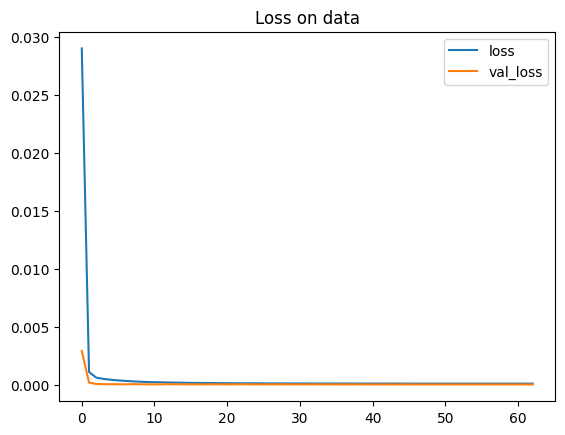

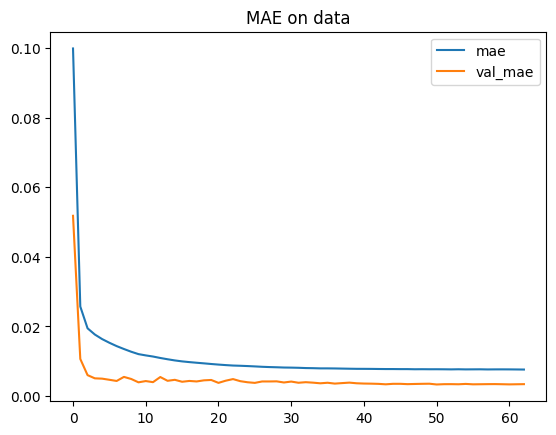

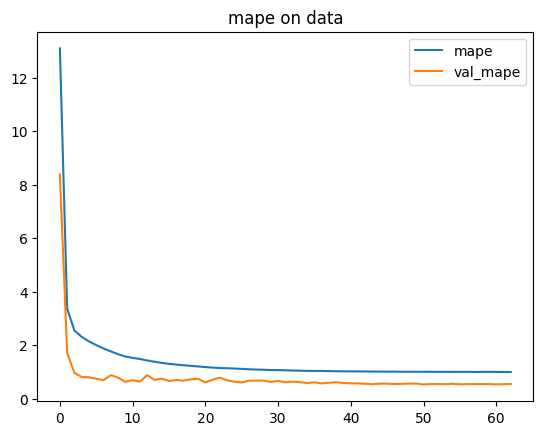

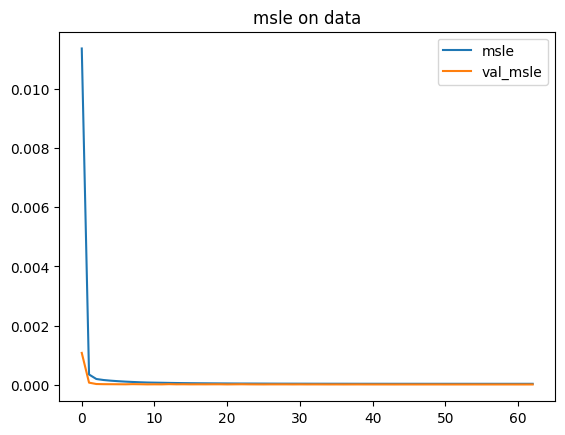

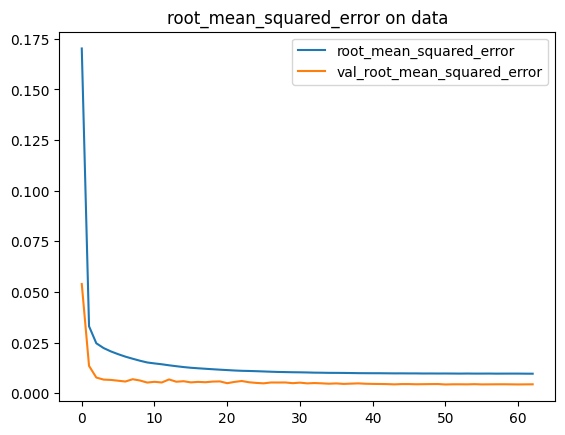

In [25]:
plt.title("Loss on data")
plt.plot(r.history['loss'], label="loss")
plt.plot(r.history['val_loss'], label="val_loss")
plt.legend()
plt.show()

plt.title("MAE on data")
plt.plot(r.history['mae'], label="mae")
plt.plot(r.history['val_mae'], label="val_mae")
plt.legend()
plt.show()

plt.title("mape on data")
plt.plot(r.history['mape'], label="mape")
plt.plot(r.history['val_mape'], label="val_mape")
plt.legend()
plt.show()

plt.title("msle on data")
plt.plot(r.history['msle'], label="msle")
plt.plot(r.history['val_msle'], label="val_msle")
plt.legend()
plt.show()

plt.title("root_mean_squared_error on data")
plt.plot(r.history['root_mean_squared_error'], label="root_mean_squared_error")
plt.plot(r.history['val_root_mean_squared_error'], label="val_root_mean_squared_error")
plt.legend()
plt.show()




In [26]:
m_label = "GeneratedGBPUSD"
best_model = load_model(m_label + 'lstm_best.keras')

In [27]:
best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 240, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 240, 128)       │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 240, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 240, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 240, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 725,771 (2.77 MB)

 Trainable params: 241,923 (945.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 483,848 (1.85 MB)

In [28]:
y_pred = best_model.predict(X_test)

789/789 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step


In [29]:
print(y_pred.shape)

(25241, 3)


In [30]:
#_,y_test = inverse_transform_data(scaled_y=y_test)
#_,y_pred = inverse_transform_data(scaled_y=y_pred)
print(y_test, " comparing to ", y_pred)

[[0.63422647 0.63356845 0.63404185]
 [0.63356845 0.63404185 0.63476141]
 [0.63404185 0.63476141 0.63536262]
 ...
 [0.62659061 0.62660954 0.62699773]
 [0.62660954 0.62699773 0.62684151]
 [0.62699773 0.62684151 0.62662848]]  comparing to  [[0.6426241  0.64105284 0.64298415]
 [0.64262533 0.64076674 0.64302456]
 [0.6425286  0.64038366 0.64299226]
 ...
 [0.6250488  0.6218365  0.6234051 ]
 [0.6252876  0.6222931  0.623972  ]
 [0.62552005 0.6228397  0.62447554]]


In [31]:
# 1. Calculate the error (the gap between actual and predicted)
error = y_test - y_pred

# 2. Calculate the average gap (the bias)
average_gap = np.mean(error)
print(f"Average Gap (Bias): {average_gap:.7f}")

# 3. Add the average gap to your predictions to create a corrected version
y_pred_corrected = y_pred + average_gap

# --- Verification ---
# Let's check the first predicted value vs. the first actual value
print("\n--- Example of Correction ---")
print(f"Original Prediction: {y_pred[0, 0]:.7f}")
print(f"Corrected Prediction: {y_pred_corrected[0, 0]:.7f}")
print(f"Actual Value:        {y_test[0, 0]:.7f}")



Average Gap (Bias): -0.0007708

--- Example of Correction ---
Original Prediction: 0.6426241
Corrected Prediction: 0.6418533
Actual Value:        0.6342265


In [32]:
print("R^2 value for ", m_label)
print(r2_score(y_test, y_pred))
print(r2_score(y_test, y_pred_corrected))

R^2 value for  GeneratedGBPUSD
0.9738028536026565
0.9746332882228216


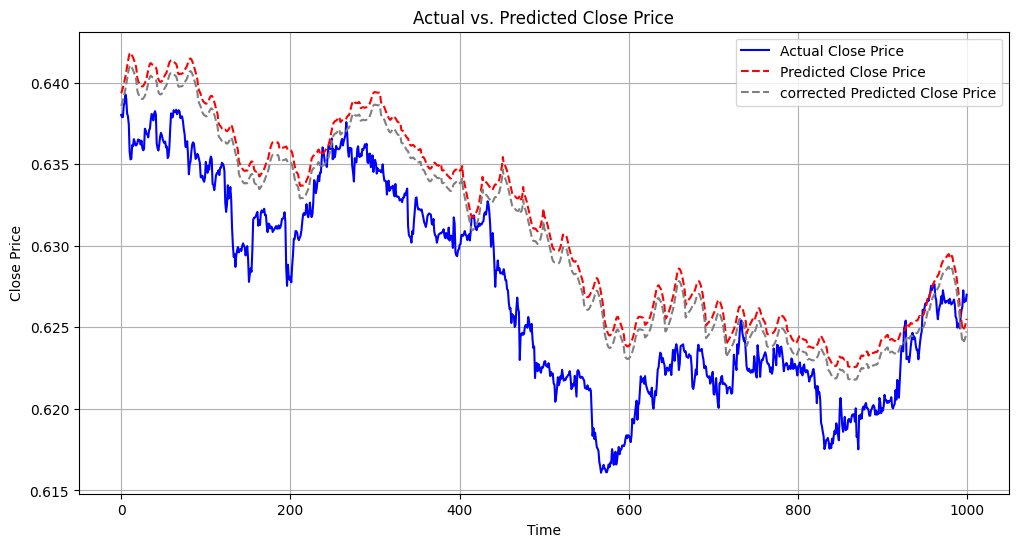

In [33]:

plt.figure(figsize=(12, 6))
plt.plot(y_test[-1000:, 0], label='Actual Close Price', color='blue')
plt.plot(y_pred[-1000:, 0], label='Predicted Close Price', color='red', linestyle='--')
plt.plot(y_pred_corrected[-1000:, 0], label='corrected Predicted Close Price', color='gray', linestyle='--')
plt.title('Actual vs. Predicted Close Price')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.savefig('actual_vs_predicted.png')
plt.show()


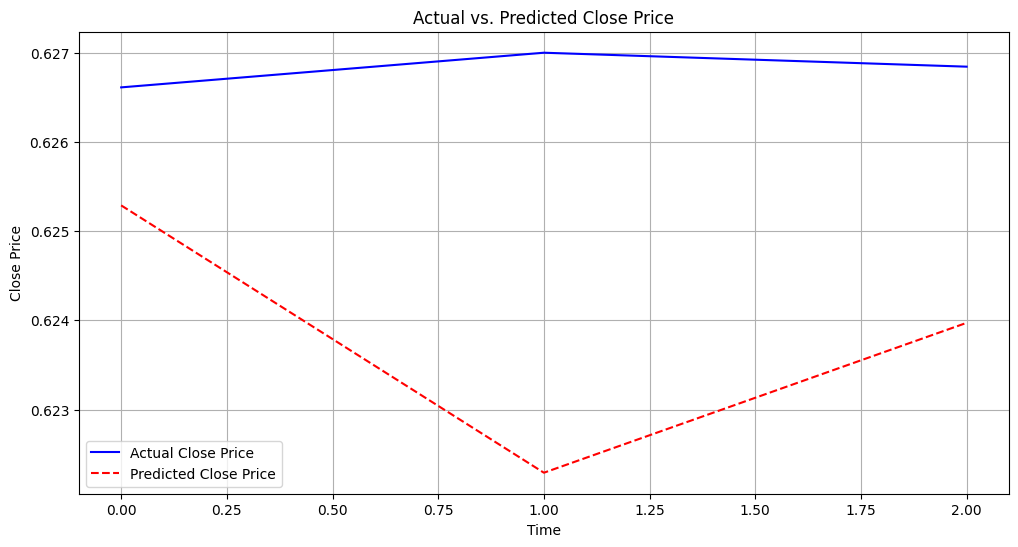

In [35]:

plt.figure(figsize=(12, 6))
plt.plot(y_test[-2, :], label='Actual Close Price', color='blue')
plt.plot(y_pred[-2, :], label='Predicted Close Price', color='red', linestyle='--')
#plt.plot(y_pred_corrected[0, :], label='corrected Predicted Close Price', color='gray', linestyle='--')
plt.title('Actual vs. Predicted Close Price')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.savefig('actual_vs_predicted.png')
plt.show()